In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn


# Importing Functions and Data

In [222]:
def load(fnm):
	return json.load(open(fnm))

def get_choices(data):
    """Pre-Processes Experiment Data

    Returns
        Right choice distance and left choice distance from the entry hole.
        The actual choice made.
        Reaction time.
    """
    choices = []
    for block in data['blocks']:
        trials = block['trials']
        for i, trial in enumerate(trials):
            if i == 0:
                continue
            if 'holes' in trial:
                hole_locs = sorted(trial['holes']['hole_locations'])
            elif 'events' in trial and len(trial['events']) > 0:
                hole_locs = sorted(trial['events'][0]['hole_locations'])
            else:
                print('no choice')
                continue
            if len(hole_locs) == 2:
                if 'holeUsed' in trial:
                    h_cur = trial['holeUsed']
                    h_prev = trials[i-1]['holeUsed']
                elif 'events' in trial and len(trial['events']) > 0 and 'events' in trials[i-1] and len(trials[i-1]['events']) > 0:
                    h_cur = trial['events'][0]['holeUsed']
                    h_prev = trials[i-1]['events'][0]['holeUsed']
                else:
                    continue
                dist_L = np.abs(hole_locs[0] - h_prev)
                dist_R = np.abs(hole_locs[1] - h_prev)
                choice = hole_locs.index(h_cur)
                if 'timePassedThru' in trial:
                    rt = trial['timePassedThru'] - trials[i-1]['timePassedThru']
                elif 'events' in trial and len(trial['events']) > 0 and len(trials[i-1]['events']) > 0:
                    rt = trial['events'][0]['time'] - trials[i-1]['events'][0]['time']
                else:
                    rt = np.nan
                choices.append((dist_L, dist_R, rt, choice))
        return np.vstack(choices)

def compare_greedy_vs_rollout(data, only_use_disagreements=False):
    """Pre-Processes Experiment Data

    Returns
        - Right choice distance and left choice distance from the entry hole.
        - 2-step distances from the beginning of the trial
        - The actual choice made
        - Reaction time: calculated the time passing through the choice level minus the time passing through the entry funnel
    """
    choices = []
    for block in data['blocks']:
        if len(block['trials']) == 4:
            continue
        
        trials = block['trials']
        for i, trial in enumerate(trials):
            if i == len(trials)-1:
                continue
            if 'holes' in trial:
                hole_locs = sorted(trial['holes']['hole_locations'])
                prev_hole_locs = sorted(trials[i-1]['holes']['hole_locations'])
                next_hole_locs = sorted(trials[i+1]['holes']['hole_locations'])
                h_cur = trial['holeUsed']
                h_prev = trials[i-1]['holeUsed']
                h_next = trials[i+1]['holeUsed']
            elif 'events' in trial and len(trial['events']) > 0 and len(trials[i-1]['events']) > 0 and len(trials[i+1]['events']) > 0:
                #print(i)
                hole_locs = sorted(trial['events'][0]['hole_locations'])
                prev_hole_locs = sorted(trials[i-1]['events'][0]['hole_locations'])
                next_hole_locs = sorted(trials[i+1]['events'][0]['hole_locations'])
                h_cur = trial['events'][0]['holeUsed']
                h_prev = trials[i-1]['events'][0]['holeUsed']
                h_next = trials[i+1]['events'][0]['holeUsed']
            else:
                hole_locs = []
                prev_hole_locs = []
                next_hole_locs = []
                h_cur = None
                h_prev = None
            if len(hole_locs) != 2 or len(prev_hole_locs) != 1 or len(next_hole_locs) != 1:
                continue

            dist_L1 = np.abs(hole_locs[0] - h_prev)
            dist_R1 = np.abs(hole_locs[1] - h_prev)
            dist_L2 = dist_L1 + np.abs(hole_locs[0] - h_next)
            dist_R2 = dist_R1 + np.abs(hole_locs[1] - h_next)
            if only_use_disagreements:
                # we ignore trials where both greedy and rollout would make the same choice
                if (dist_L1 < dist_R1 and dist_L2 < dist_R2) or (dist_R1 < dist_L1 and dist_R2 < dist_L2):
                    continue
            
            choice = hole_locs.index(h_cur)
            if 'timePassedThru' in trial:
                rt = trial['timePassedThru'] - trials[i-1]['timePassedThru']
            elif 'events' in trial and len(trial['events']) > 0 and len(trials[i-1]['events']) > 0:
                rt = trial['events'][0]['time'] - trials[i-1]['events'][0]['time']
            else:
                rt = np.nan
            choices.append((dist_L1, dist_R1, dist_L2, dist_R2, rt, choice))
    return np.vstack(choices)

def get_switches_per_level(data):

    switches_per_level = []

    for block in data['blocks']:
        if 'user_inputs' not in block:
            continue
            
        input_times = np.array(block['user_inputs']['time'])
        input_vals = np.array(block['user_inputs']['input'])
        
        trials = block['trials']
        
        for i, trial in enumerate(trials):
            if i == 0:
                continue
                
            if 'events' in trial and len(trial['events']) > 0 and len(trials[i-1]['events']) > 0:
                t_start = trials[i-1]['events'][0]['time']
                t_end = trial['events'][0]['time']
            elif 'timePassedThru' in trial:
                t_start = trials[i-1]['timePassedThru']
                t_end = trial['timePassedThru']
            else:
                continue 
            mask = (input_times > t_start) & (input_times <= t_end)
            level_inputs = input_vals[mask]
            
            if len(level_inputs) > 0:
                changes = np.diff(level_inputs)
                
                num_switches = np.count_nonzero(changes)
            else:
                num_switches = 0
                
            switches_per_level.append(num_switches)
            
    return np.array(switches_per_level)

# Analysis Functions

In [223]:
def plot_rt_residuals_histogram(choices, rt_regression_type='linear', bins=50, fig=None):
   
    # 1. Extract columns from the compare_greedy_vs_rollout output
    dist_L1 = choices[:, 0]
    dist_R1 = choices[:, 1]
    rts = choices[:, 4]
    choice_made = choices[:, 5]

    # Filter out trials with NaN reaction times
    valid_mask = ~np.isnan(rts)
    dist_L1, dist_R1 = dist_L1[valid_mask], dist_R1[valid_mask]
    rts = rts[valid_mask]
    choice_made = choice_made[valid_mask]

    # 2. Regress RT vs the chosen 1-step distance to get residuals
    chosen_dist_1 = np.where(choice_made == 0, dist_L1, dist_R1)

    predicted_rts = np.zeros_like(rts)

    if rt_regression_type == 'linear':
        slope, intercept = np.polyfit(chosen_dist_1, rts, 1)
        predicted_rts = (slope * chosen_dist_1) + intercept
    elif rt_regression_type == 'minimum':
        unique_distances = np.unique(chosen_dist_1)
        for d in unique_distances:
            idx = chosen_dist_1 == d
            min_rt_for_d = np.min(rts[idx])
            predicted_rts[idx] = min_rt_for_d

    residuals = rts - predicted_rts

    if fig is None:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=300)
    else:
        # If a figure is passed in, clear it and add two subplots
        fig.clf()
        ax1 = fig.add_subplot(1, 2, 1)
        ax2 = fig.add_subplot(1, 2, 2)

    lower_bound = np.percentile(residuals, 1)
    upper_bound = np.percentile(residuals, 99)
    clean_residuals = residuals[(residuals >= lower_bound) & (residuals <= upper_bound)]

    ax1.hist(residuals, bins=bins, color='lightcoral', edgecolor='black', alpha=0.8)
    ax1.set_xlabel('Reaction Time Residual (ms)')
    ax1.set_ylabel('Frequency')
    ax1.set_title('With Outliers')
    ax1.axvline(0, color='red', linestyle='--', linewidth=2, label=f'Expected RT (N={len(residuals)})')
    ax1.legend(loc='upper right')

    ax2.hist(clean_residuals, bins=bins, color='skyblue', edgecolor='black', alpha=0.8)
    ax2.set_xlabel('Reaction Time Residual (ms)')
    ax2.set_ylabel('Frequency')
    ax2.set_title('No Outliers')
    ax2.axvline(0, color='red', linestyle='--', linewidth=2, label=f'Expected RT (N={len(clean_residuals)})')
    ax2.legend(loc='upper right')

    # Ensure the plots don't squish together
    fig.tight_layout()
    
    return fig

def plot_psychometric_curve(X, y, fig=None, color='k', xlabel='Δ Distance to hole (L - R)', label='_'):
    """Plots a Psychometric curve

    Inputs:
        - X: difference between the 1-step left distance and 1-step right distance
        - y: the actual choice made

    Returns:
        - A psychometric curve
    """

    xs = np.unique(X)
    ys = []
    ses = []
    for x in xs:
        ix = X == x
        ymu = np.nanmean(y[ix])
        ys.append(ymu)
        ses.append(np.nanstd(y[ix]) / np.sqrt(sum(ix)))

    if fig is None:
        plt.figure(figsize=(3,3), dpi=300)
    for x,y,se in zip(xs,ys,ses):
        plt.plot([x,x],[y-se,y+se],'-', color=color, alpha=0.3)
    plt.plot(xs, ys, '.-', color=color, label=label)
    plt.xlabel(xlabel)
    plt.ylabel('Prob. of choosing Right Hole')
    return fig

def plot_switch_distribution(data):
    """
    Plots a histogram showing how frequently users switched directions per level.
    """
    switches = get_switches_per_level(data)
    
    if len(switches) == 0:
        print("No valid user inputs found in the data.")
        return

    fig, ax = plt.subplots(figsize=(8, 5))
    
    max_switches = np.max(switches)
    bins = np.arange(-0.5, max_switches + 1.5, 1)
    
    ax.hist(switches, bins=bins, color='coral', edgecolor='black', alpha=0.8)
    
    # Formatting
    ax.set_xticks(range(max_switches + 1))
    ax.set_title('Distribution of Direction Switches Per Level')
    ax.set_xlabel('Number of Switches (per level)')
    ax.set_ylabel('Frequency (Number of Levels)')
    
    plt.tight_layout()
    plt.show()

def plot_trials_per_block(data, fig=None):
    """
    Extracts the number of trials in each block and plots it as a line graph.
    """
    block_numbers = []
    trial_counts = []

    # 1. Extract the data
    for i, block in enumerate(data['blocks']):
        # If your blocks are 0-indexed but you want the graph to start at Block 1, use i + 1
        block_numbers.append(i + 1) 
        
        # Count the number of trials in this specific block
        if 'trials' in block:
            trial_counts.append(len(block['trials']))
        else:
            trial_counts.append(0)  # Safe fallback if a block is totally empty

    block_numbers = block_numbers[1:]
    trial_counts = trial_counts[1:]

    # 2. Create the Plot
    if fig is None:
        fig = plt.figure(figsize=(8, 5), dpi=300)

    # Plot the line with 'o' markers to clearly show each individual block
    plt.plot(block_numbers, trial_counts, marker='o', linestyle='-', color='indigo', linewidth=2, markersize=6)

    # 3. Formatting
    plt.title('Number of Trials per Block')
    plt.xlabel('Block Number')
    plt.ylabel('Total Trials')
    
    # Force the X-axis to only show whole numbers (since you can't have Block 1.5)
    plt.xticks(block_numbers)
    
    # Add a subtle grid to make it easier to read across
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    
    return fig

# Merging Shitty Data Functions

In [99]:
import os
import glob
import json
from collections import defaultdict

In [103]:
def merge_participant_files(folder_path, participant_id):
    # Find all JSON files for this specific participant
    search_pattern = os.path.join(folder_path, f"{participant_id}*.json")
    file_list = glob.glob(search_pattern)

    if not file_list:
        print(f"No files found for participant {participant_id}")
        return {'blocks': []}

    # 1. Deduplicate Phase
    # Use nested dictionaries so that overlapping trials overwrite each other safely
    merged_blocks = {}

    for file_path in file_list:
        try:
            with open(file_path, 'r') as f:
                data = json.load(f)
                
            if 'blocks' not in data:
                continue
                
            for block in data['blocks']:
                b_idx = block.get('block_index')
                if b_idx is None:
                    continue
                    
                if b_idx not in merged_blocks:
                    merged_blocks[b_idx] = {}
                    
                if 'trials' not in block:
                    continue
                    
                for trial in block['trials']:
                    t_idx = trial.get('index')
                    if t_idx is not None:
                        merged_blocks[b_idx][t_idx] = trial
                        
        except Exception as e:
            print(f"Error processing {file_path}: {e}")

    # 2. Strict List Conversion Phase
    # compare_greedy_vs_rollout requires pure lists to allow for enumerate() and trials[i-1] indexing
    final_data = {'blocks': []}
    
    # Sort blocks to ensure chronological order (0, 1, 2...)
    for b_idx in sorted(merged_blocks.keys()):
        block_dict = {
            'block_index': b_idx,
            'trials': [] # Force trials to be a pure List
        }
        
        # Sort trials within the block to guarantee chronological sequence
        for t_idx in sorted(merged_blocks[b_idx].keys()):
            block_dict['trials'].append(merged_blocks[b_idx][t_idx])
            
        final_data['blocks'].append(block_dict)

    return final_data

In [104]:
clean_participant_data = merge_participant_files('./cloud study data', '09068BB9E6224A029F04C83C05132718')

# Output

In [241]:
#fd = "C:/Users/manik/Desktop/Obsidian/General Thoughts/Z Images and Files/Hennig Lab Project/falldown/logs"
data = load("cloud study data/CEFD2FE92E6847B2B27FF0175811CE81-019e9464-988c-7240-bf66-336f77c05049-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T20-50-03-371Z-34zm.json")

In [238]:
data['blocks'][0]['trials']

[{'index': 0,
  'block_index': 0,
  'hole_locations': [3],
  'events': [{'index': 1,
    'levelY': 323.5,
    'modeIndex': 0,
    'isModeSwitch': False,
    'holeUsed': 3,
    'ballTouched': True,
    'timeBallFirstTouched': 13259.199999928474,
    'cameraMode': 0,
    'ballX': 415.264,
    'ballY': 363.56933333333336,
    'cameraY': 18.48529939778647,
    'scrollSpeed': 1.6175000000000002,
    'trial_index': 0,
    'hole_locations': [3],
    'block_index': 0,
    'time': 21985.599999904633}]},
 {'index': 1,
  'block_index': 0,
  'hole_locations': [5],
  'events': [{'index': 2,
    'levelY': 415.92857142857144,
    'modeIndex': 0,
    'isModeSwitch': False,
    'holeUsed': 5,
    'ballTouched': True,
    'timeBallFirstTouched': 22049.899999976158,
    'cameraMode': 0,
    'ballX': 666.608,
    'ballY': 455.9979047619048,
    'cameraY': 110.9137323769883,
    'scrollSpeed': 1.6175000000000002,
    'trial_index': 1,
    'hole_locations': [5],
    'block_index': 0,
    'time': 22749.79999

In [ ]:
for block in data['blocks']:
    print(block['block_index'])

0
1
2
2
3
4
5
5
5
5
5
5
6
7
7
7
7
7
8
9
9
9
9
10
11
11
11
12
13
13
13
13
14
15
15
15
15
16
17
17
17
17
18
19
19
19
19
20
21
21
21
21
22
23
23
23
23
24
25
25
26
27
27
27
28
29
29
29
30
31
31
32
33
33
33


: 

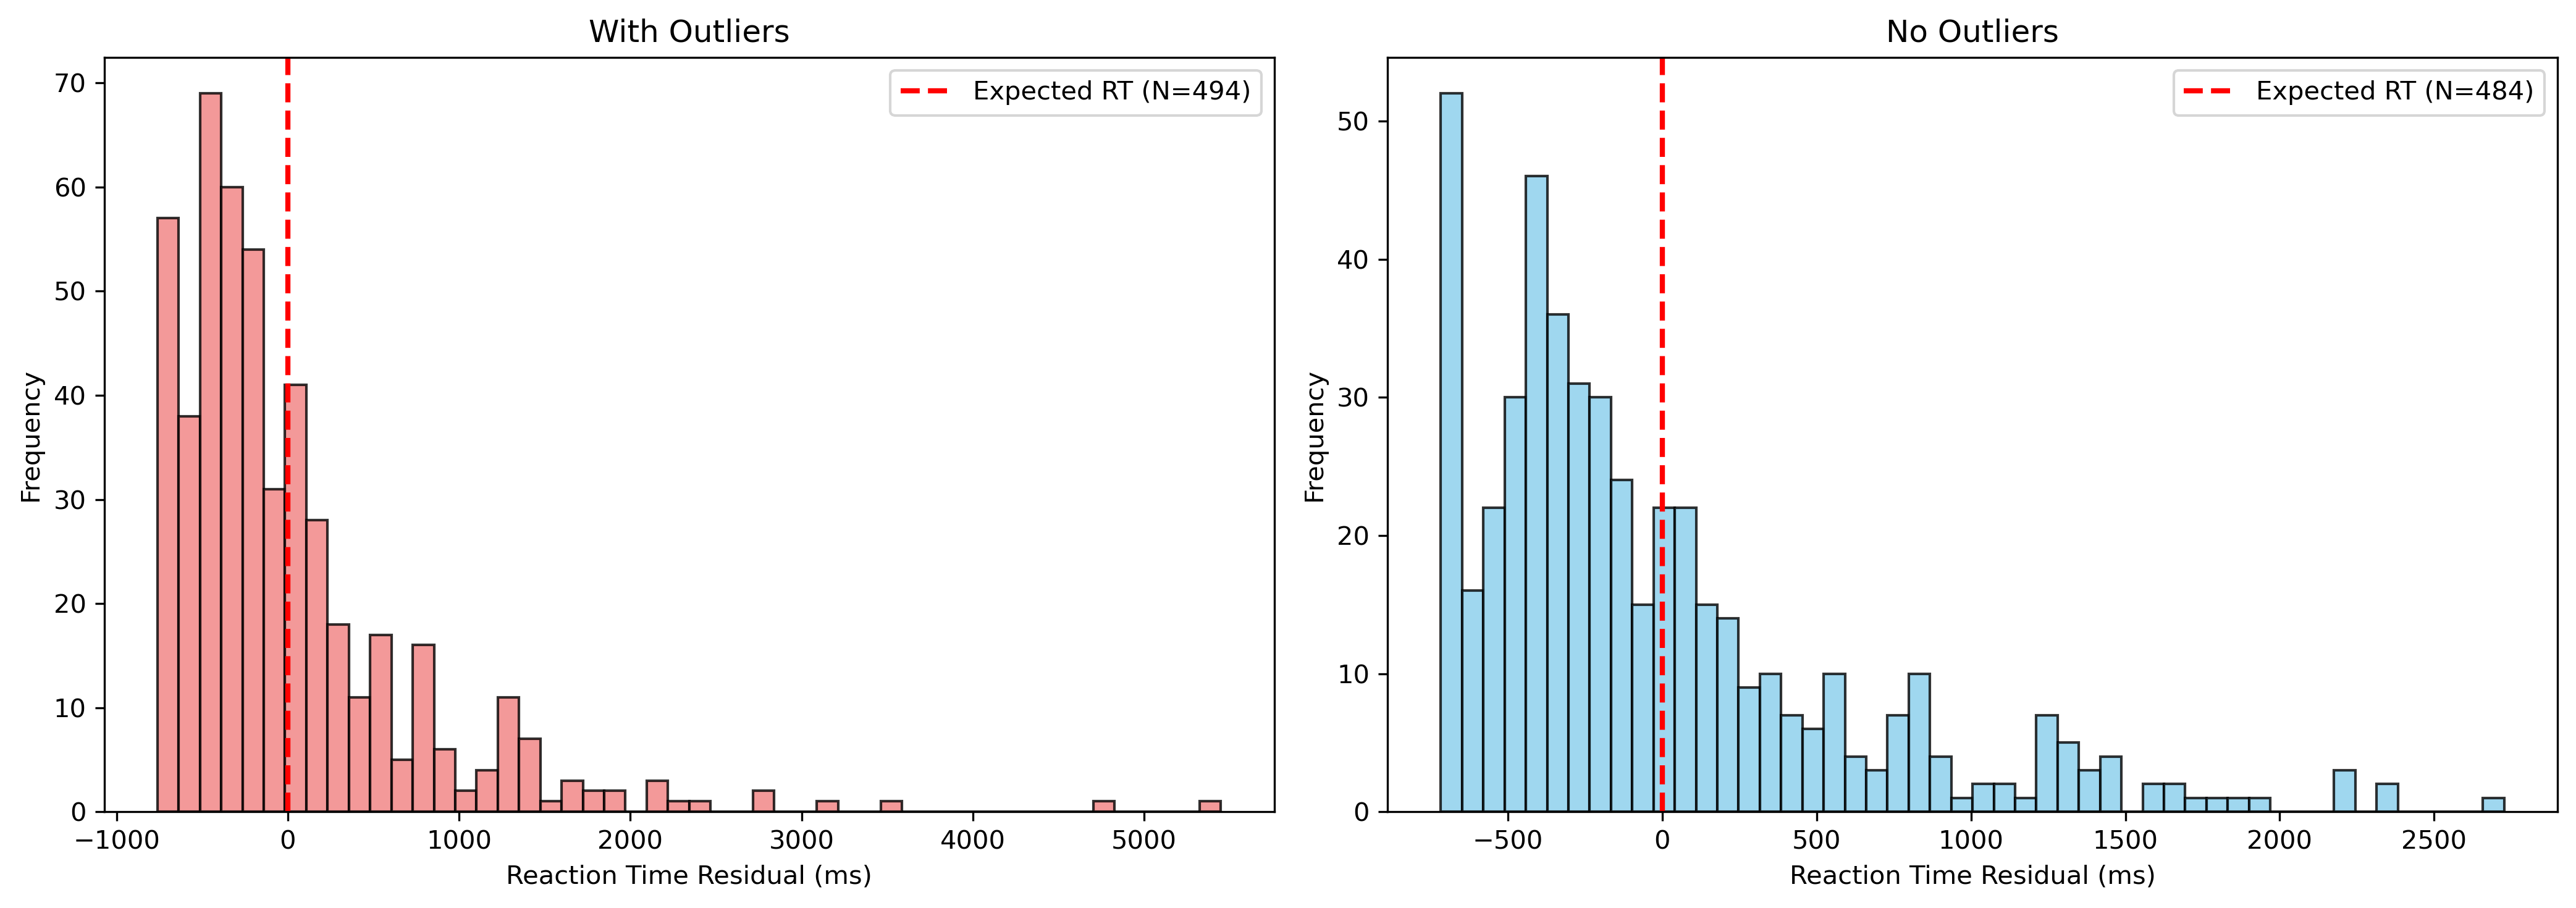

In [230]:
choices = compare_greedy_vs_rollout(data, only_use_disagreements=False)
histogram = plot_rt_residuals_histogram(choices)

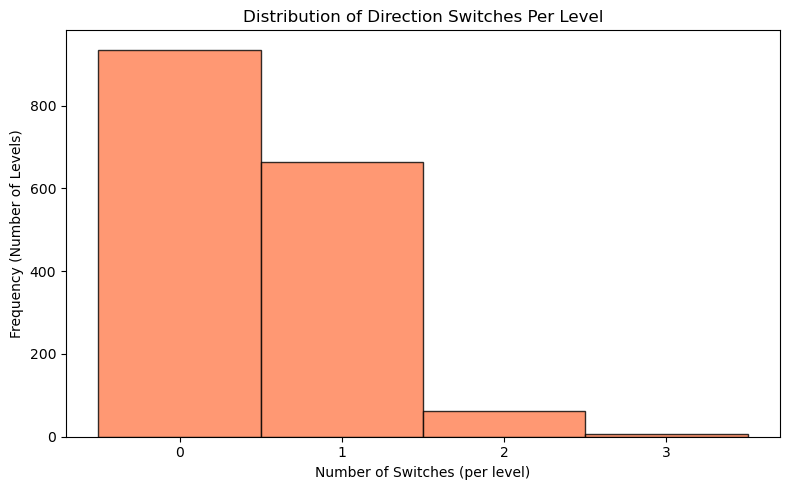

In [232]:
plot_switch_distribution(data)

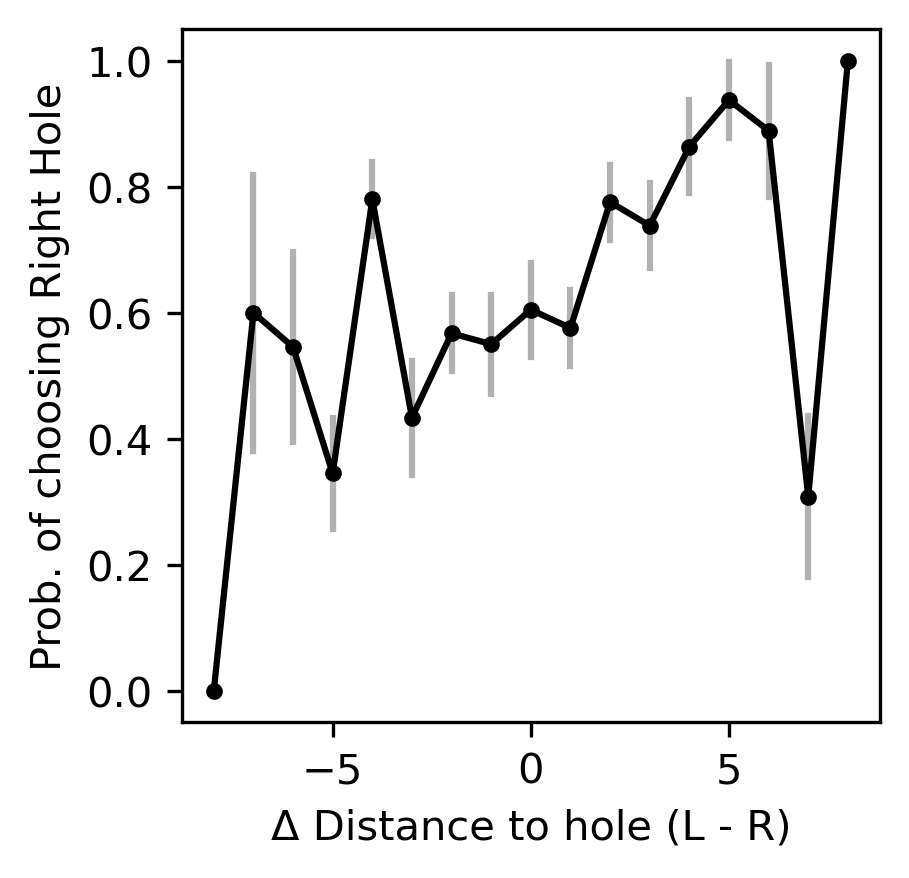

In [233]:
#choices = get_choices(data)
X = choices[:,0] - choices[:,1]
# X = choices[:,2] - choices[:,3]
y = choices[:,-1]
plot_psychometric_curve(X, y)


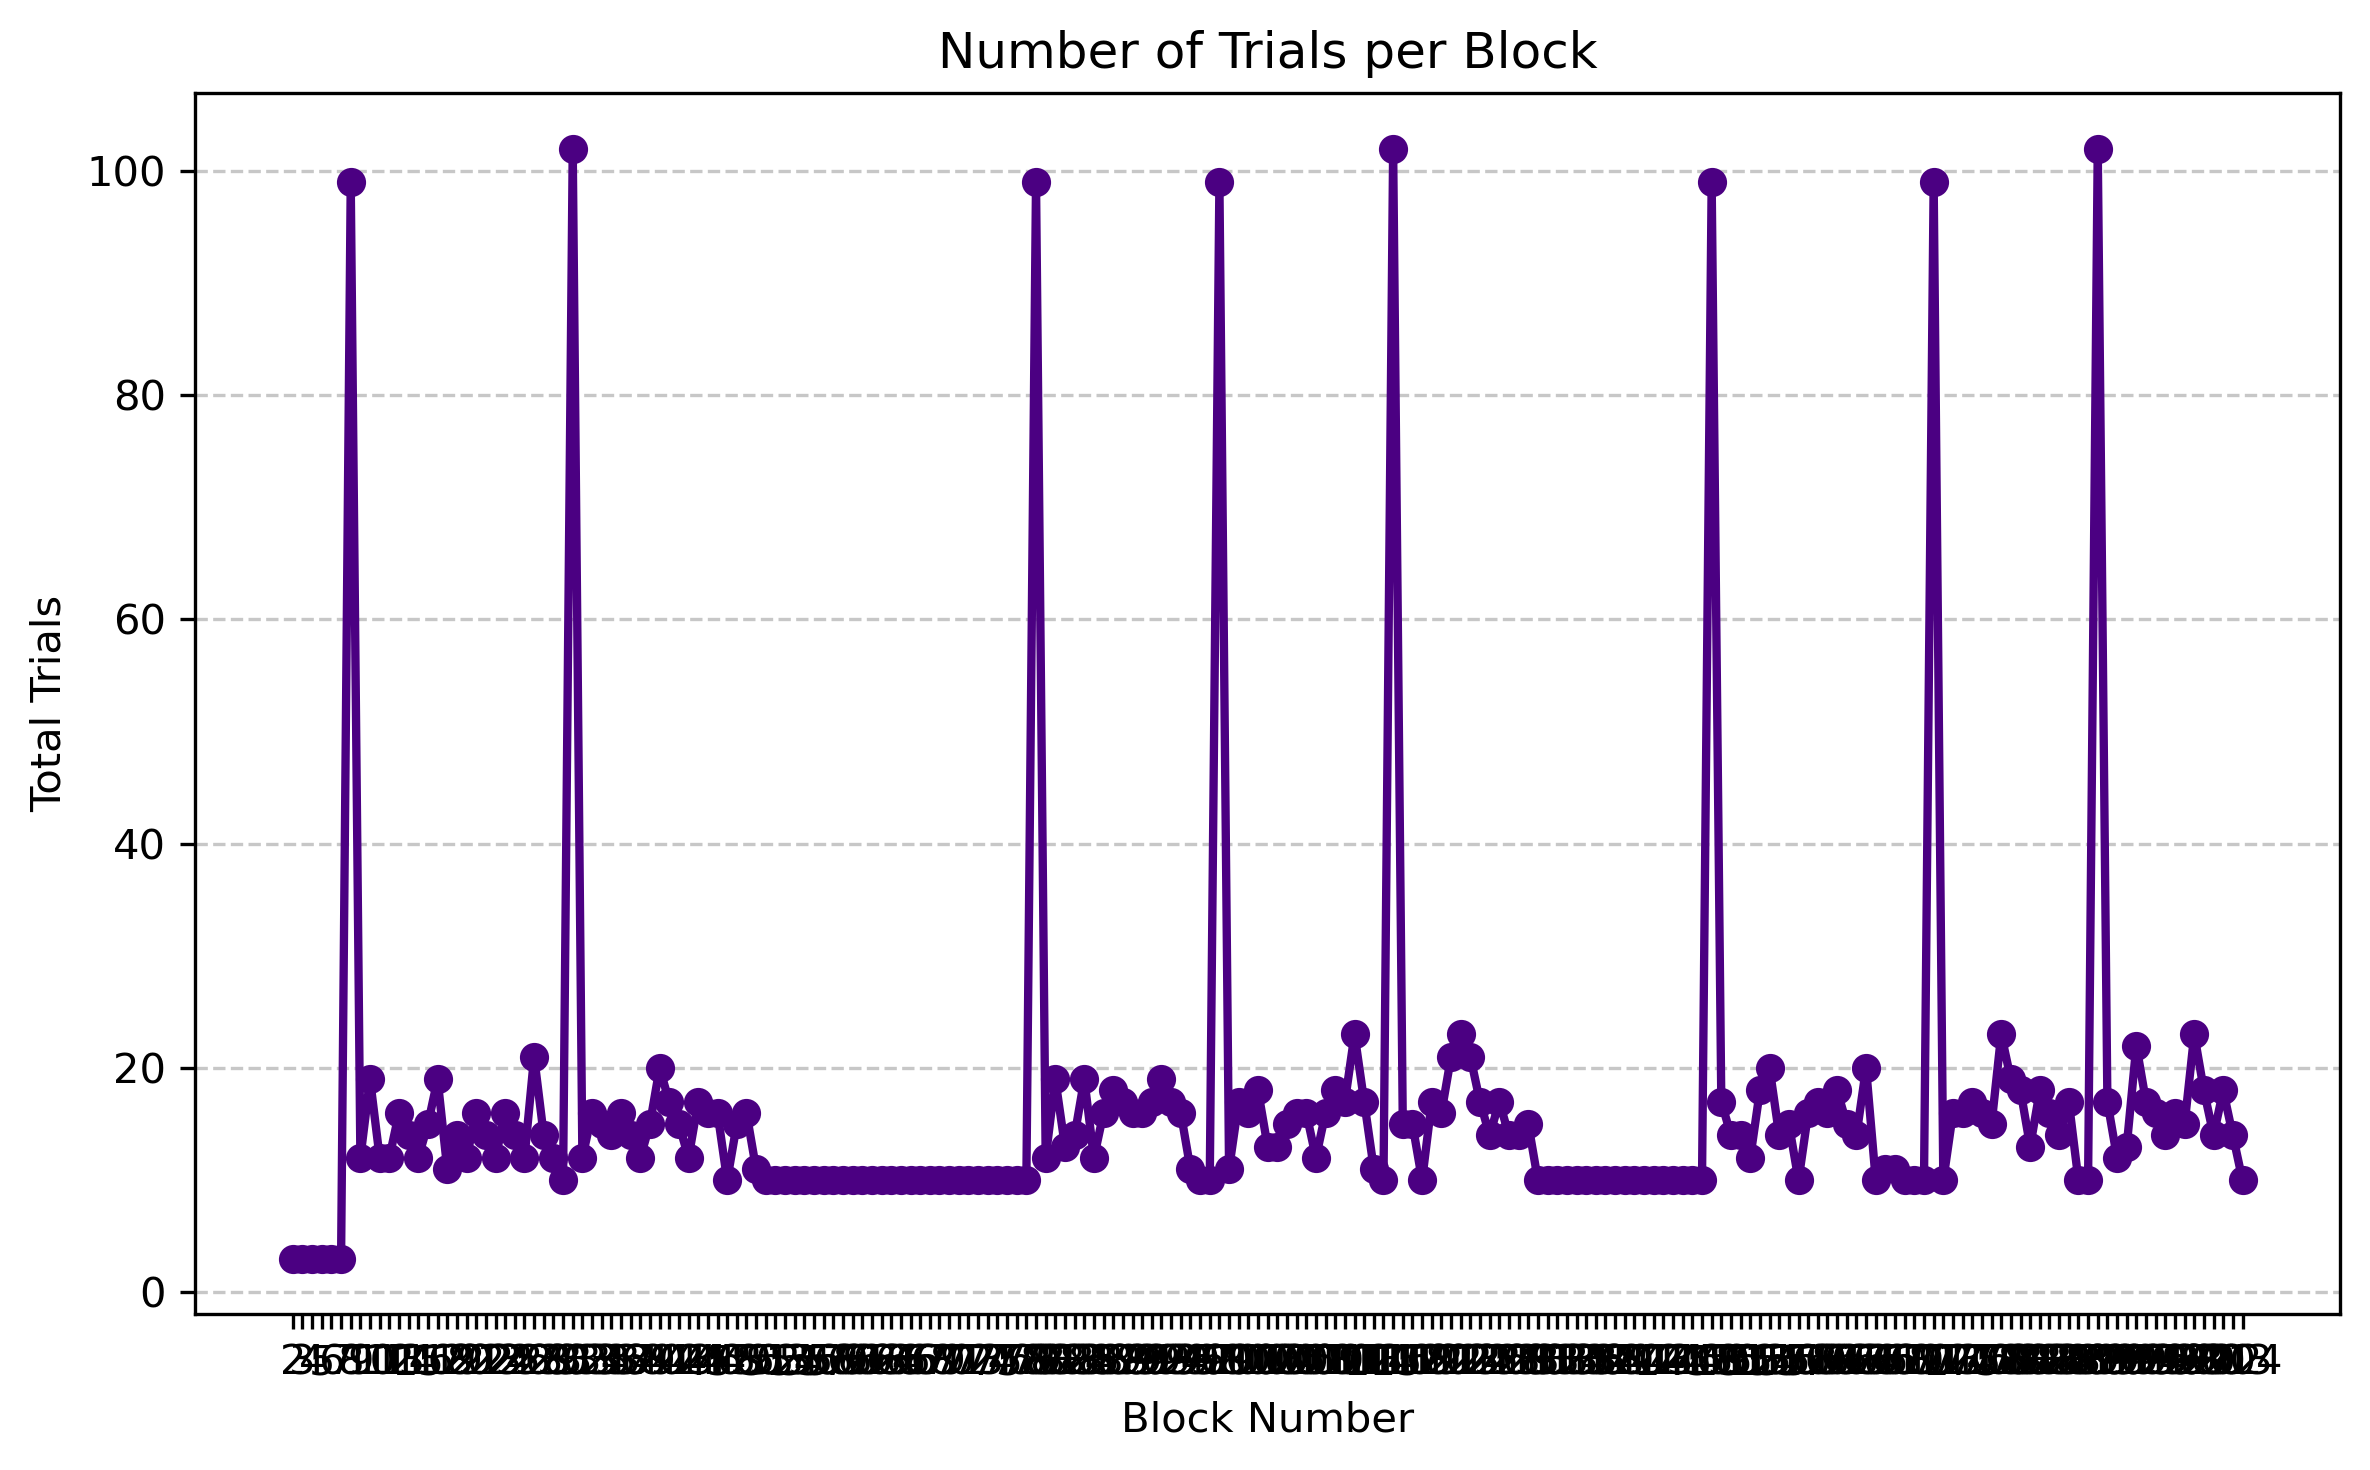

In [234]:
trials_per_block = plot_trials_per_block(data)